In [1]:
# Load packages
import os, warnings
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import cartopy.crs as crs
import cartopy.feature as cfeature
warnings.simplefilter("ignore")

In [2]:
os.chdir(r'G:\Theses\egaglo_scratch_0409\egaglo\IGCM_OUT\OL2\TEST\test\FG.CRUJRA_extract_for_FF')

In [3]:
global_data_sechiba_18 = xr.open_dataset("FG.CRUJRA.ESA.LUC_20180101_20181231_1M_sechiba_history.nc")
Sn_Nkr_data_sechiba_10_18 = xr.open_dataset("Sn_Nkr_FG.CRUJRA.ESA.LUC_2010_2018_1M_sechiba_history.nc")

In [5]:
min_lon = -18     #-16.4535
min_lat = 12      #14.495810
max_lon = -11.75     #-15.432247
max_lat = 17      #15.403124
_d = global_data_sechiba_18.copy()
mask_lon = (_d.lon >= min_lon) & (_d.lon <= max_lon)
mask_lat = (_d.lat >= min_lat) & (_d.lat <= max_lat)

SEN_cru_sech = _d.where(mask_lon & mask_lat, drop=True)

del _d

In [ ]:
# Liste des PFTs à afficher
veget = [2, 3, 11, 13]

PFT_dict = {
    1.: ('bare soil', 'sol nu'),
    2.: ('tropical broad-leaved evergreen', 'Forêt tropicale\nde feuillus sempervirents'),
    3.: ('tropical broad-leaved decidious', 'Forêt tropicale\nde feuillus décidus'),
    4.: ('temperate needleleaf evergreen', 'Forêt tempérée\nde conifères sempervirents'),
    5.: ('temperate broad-leaved evergreen', 'Forêt tempérée\nde feuillus sempervirents'),
    6.: ('temperate broad-leaved summergreen', 'Forêt tempérée\nde feuillus décidus'),
    7.: ('boreal needleleaf evergreen', 'Forêt boréale\nde conifères sempervirents'),
    8.: ('boreal broad-leaved summergreen', 'Forêt boréale\nde feuillus décidus'),
    9.: ('boreal needleleaf summergreen', 'Forêt boréale\nde conifères décidus'),
    10.: ('C3 grass', 'Herbacées naturelles en C3'),
    11.: ('C4 grass', 'Herbacées naturelles en C4'),
    12.: ('C3 agriculture', 'Cultures en C3'),
    13.: ('C4 agriculture', 'Cultures en C4'),
    14.: ('Tropical C3 grassland', 'Prairie tropicale en C3'),
    15.: ('Boreal C3 grassland', 'Prairie boréale en C3')
}

In [75]:
def plot_vegetation_maps(data, title_label, vmin=0, vmax=0.8, cmap="YlGn", 
                         colorbar_label='Fraction maximale de la végétation (%)',
                         points=None):
    # Créer la figure et les axes
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(7, 5),
                            subplot_kw={'projection': crs.PlateCarree()})

    # Ajuster manuellement les positions des axes
    for i, ax in enumerate(axes.flat):
        ax.set_position([0.1 + (i % 2) * 0.4, 0.5 - (i // 2) * 0.45, 0.4, 0.4])

    # Tracer les données et enregistrer les objets QuadMesh pour la colorbar
    quadmesh_objects = []
    for ax, (v, subset) in zip(axes.flat, data.groupby('veget')):
        quadmesh = subset.plot(ax=ax, cmap=cmap, add_colorbar=False, vmin=vmin, vmax=vmax)
        quadmesh_objects.append(quadmesh)
        ax.set_title(PFT_dict[v][1], fontsize=11)
        ax.coastlines(lw=1)
        ax.add_feature(cfeature.BORDERS)
        
        # Ajouter les points d'intérêt si fournis
        if points:
            for point_name, lon, lat, color in points:
                ax.plot(lon, lat, f'{color}o', markersize=5, transform=crs.PlateCarree())
                
                # Ajustement du placement du texte selon le point
                if point_name == 'Dakar':
                    ax.text(lon+0.35, lat-0.08, point_name, fontsize=10,
                            horizontalalignment='right', verticalalignment="top", 
                            transform=crs.PlateCarree())
                elif point_name == 'Niakhar':
                    ax.text(lon, lat+0.05, point_name, fontsize=10, color="red",
                            horizontalalignment='left', verticalalignment="bottom", 
                            transform=crs.PlateCarree())

    # Ajouter la colorbar
    cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])
    cbar = fig.colorbar(quadmesh_objects[0], cax=cbar_ax, orientation='vertical')
    cbar.set_label(colorbar_label, fontsize=12)

    # Configurer les ticks de la colorbar si nécessaire
    if vmax <= 1:
        cbar.set_ticks(np.round(np.arange(0, vmax+0.1, 0.1), 1).tolist())
        cbar.set_ticklabels(np.arange(0, int(vmax*100)+10, 10).tolist())

    # Ajouter un label optionnel
    if title_label:
        axes[0, 0].text(-0.1, 1.05, title_label, 
                        transform=axes[0, 0].transAxes, size=14, weight='bold')

    plt.show()



In [92]:
result_map = SEN_cru_sech.maxvegetfrac.mean(dim='time_counter').sel(veget=veget)

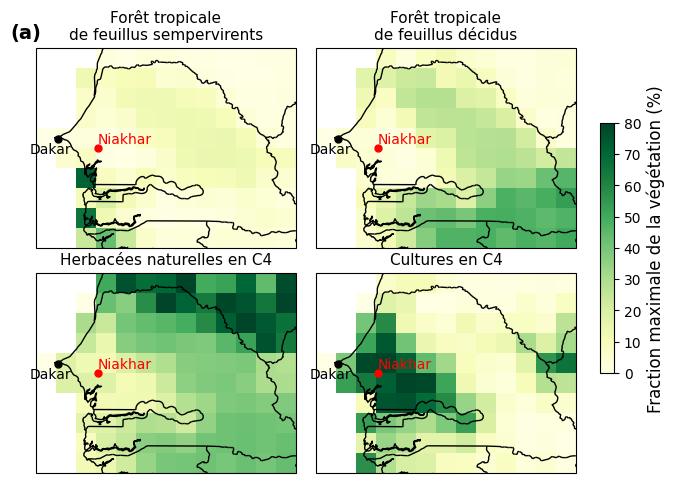

In [93]:
# PFTs proportion
plot_vegetation_maps(result_map, '(a)', 
                     points=[('Dakar', -17.461308570312504, 14.722705571455728, 'k'), 
                             ('Niakhar', -16.4535, 14.495810, 'r')])



In [7]:
SEN_cru_sech.gpp

<xarray.DataArray 'gpp' (time_counter: 12, veget: 15, lat: 10, lon: 13)>
array([[[[          nan,           nan,           nan, ...,
          0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [          nan,           nan, 0.0000000e+00, ...,
          0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [          nan,           nan, 0.0000000e+00, ...,
          0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         ...,
         [          nan,           nan, 0.0000000e+00, ...,
          0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [          nan,           nan, 0.0000000e+00, ...,
          0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [          nan,           nan, 0.0000000e+00, ...,
          0.0000000e+00, 0.0000000e+00, 0.0000000e+00]],

        [[          nan,           nan,           nan, ...,
          3.3254035e-09, 1.3308404e-08, 1.8073019e-08],
         [          nan,           nan, 4.7098322e-07, ...,
          1.3857976e-08, 2.0103476e-08, 3.3952293e-08],
         [          nan,           nan, 2.9299235e-07, ...,
          4.1491759e-08, 3.2546726e-08, 7.5123346e-08],
...
         [          nan,           nan, 0.0000000e+00, ...,
          0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [          nan,           nan, 0.0000000e+00, ...,
          0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [          nan,           nan, 0.0000000e+00, ...,
          0.0000000e+00, 2.3117668e-08, 0.0000000e+00]],

        [[          nan,           nan,           nan, ...,
          0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [          nan,           nan, 0.0000000e+00, ...,
          0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [          nan,           nan, 0.0000000e+00, ...,
          0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         ...,
         [          nan,           nan, 0.0000000e+00, ...,
          0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [          nan,           nan, 0.0000000e+00, ...,
          0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
         [          nan,           nan, 0.0000000e+00, ...,
          0.0000000e+00, 0.0000000e+00, 0.0000000e+00]]]], dtype=float32)
Coordinates:
  * lat            (lat) float32 16.75 16.25 15.75 15.25 ... 13.25 12.75 12.25
  * lon            (lon) float32 -17.75 -17.25 -16.75 ... -12.75 -12.25 -11.75
  * veget          (veget) float32 1.0 2.0 3.0 4.0 5.0 ... 12.0 13.0 14.0 15.0
    time_centered  (time_counter) object ...
  * time_counter   (time_counter) object 2018-01-16 12:00:00 ... 2018-12-16 1...
Attributes:
    long_name:           Net assimilation of carbon by the vegetation
    units:               gC/m^2/s
    online_operation:    average
    interval_operation:  1800 s
    interval_write:      1 month
    cell_methods:        time: mean (interval: 1800 s)

In [94]:
# a=gpp*maxveget*60*60*24*30
# b une valuer mensuelle = aggrégation (sum de a ) #gC/m²/month
#c une valeur annuelle =  aggrégation (sum de b )*0.01 #tC/ha/an
result_gpp = (SEN_cru_sech.gpp * SEN_cru_sech.maxvegetfrac * 60 * 60 * 24 * 30).sum(dim='time_counter') * 0.01


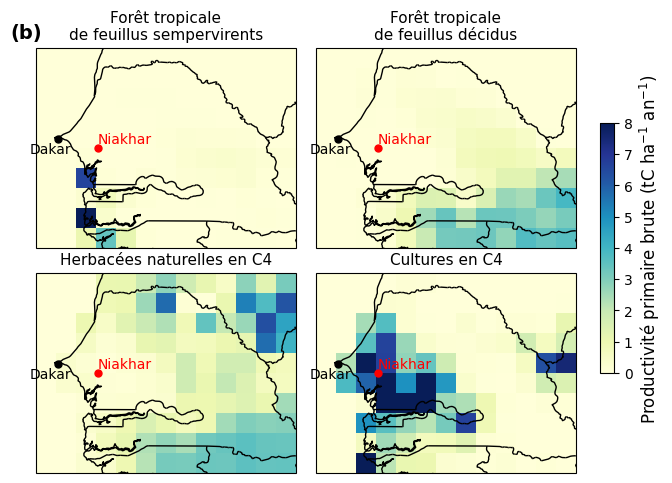

In [95]:
# GPP
plot_vegetation_maps(result_gpp.sel(veget=veget), '(b)', vmin=0, vmax=8, cmap="YlGnBu",
                     colorbar_label='Productivité primaire brute (tC ha$^{-1}$ an$^{-1}$)',
                     points=[('Dakar', -17.461308570312504, 14.722705571455728, 'k'), 
                             ('Niakhar', -16.4535, 14.495810, 'r')])

In [98]:
SEN_cru_sech.fluxlat.sel(lat=lat_nia, lon=lon_nia, method="nearest").to_dataframe()

,lat,lon,time_centered,fluxlat
time_counter,,,,
2018-01-16 12:00:00,14.25,-16.25,2018-01-16 12:00:00,0.622033
2018-02-15 00:00:00,14.25,-16.25,2018-02-15 00:00:00,0.679670
2018-03-16 12:00:00,14.25,-16.25,2018-03-16 12:00:00,0.719420
2018-04-16 00:00:00,14.25,-16.25,2018-04-16 00:00:00,1.312132
2018-05-16 12:00:00,14.25,-16.25,2018-05-16 12:00:00,0.716306
2018-06-16 00:00:00,14.25,-16.25,2018-06-16 00:00:00,15.447164
2018-07-16 12:00:00,14.25,-16.25,2018-07-16 12:00:00,68.909851
2018-08-16 12:00:00,14.25,-16.25,2018-08-16 12:00:00,115.835060
2018-09-16 00:00:00,14.25,-16.25,2018-09-16 00:00:00,123.140900
